# Evaluate the performance of different models on specific Benchmarks
- Report Generation: MIMIC-CXR
- VQA: MS-CXR, RADVQA?
- Detection: VinDR?

In [ ]:
# pip install accelerate
# from transformers import AutoProcessor, AutoModelForImageTextToText
# import torch

import os
from tqdm import tqdm
import random
import json
import sys
sys.path.append('/path/to/anatomix/')

from src.data.llm_data import LLMData
from src.data.scenegraph_data import get_transforms

In [ ]:
os.environ["http_proxy"]="http://172.28.7.1:3128"
os.environ["https_proxy"]="http://172.28.7.1:3128"
os.environ["all_proxy"]="http://172.28.7.1:3128"
os.environ["no_proxy"]="localhost,*.chimera.hpc.mssm.edu,172.28.0.0/16"

In [ ]:

def data_init(dataset_name="mimic_vqa", split='test', subset = 0.1):
    import random
    import numpy as np
    import torch

    seed = 2025
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # transforms = get_transforms()

    dataset = LLMData(
        split = split,
        data_dir = "/path/to/data/datasets/mydataset/",
        image_dir = "/path/to/data/vlm_chest_xray/images",
        dataset_names = [dataset_name],
        # transforms = transforms,
        system_prompts = [""],
        subset=subset,
        return_metadata=True
    )

    return dataset

## MedGemma

In [ ]:


from src.util.llm_utils import  medgemma_init, medgemma_res, postprocess_llm_output

In [ ]:
model, processor = medgemma_init(device='cuda:1')

In [ ]:
datasets = ["mimic_vqa", "mimic_report_gen"]

In [ ]:
dataset = data_init(dataset_name=datasets[1], split='test', subset=0.01)



In [ ]:
data = {}
for sample in tqdm(dataset, total=len(dataset)):
    prompt = f"Image: <start_of_image> {sample['text'][1]['content'].split('Task: ')[-1]}"
    res = sample['text'][-1]['content']        

    out = medgemma_res([sample['images']], prompt, processor, model, max_new_tokens=250)
    out = postprocess_llm_output(out)
    
    image_ids = data.setdefault('image_ids', [])
    image_ids.append(sample['image_id'])

    prompts = data.setdefault('prompts', [])
    prompts.append(prompt)

    gt_res = data.setdefault('gt_res', [])
    gt_res.append(res)
    
    model_res = data.setdefault('model_res', [])
    model_res.append(out)

    break


In [ ]:
import pandas as pd

In [ ]:
for sample in dataset:
    # sample = dataset[23]
    prompt = f"Image: <start_of_image> {sample['text'][1]['content'].split('Task: ')[-1]}"
    print(prompt)

In [ ]:
df = pd.DataFrame.from_dict(data)

In [ ]:
df['gt_res']

In [ ]:
print(df['model_res'].tolist()[0])

In [ ]:
sample = dataset[123]

In [ ]:
sample.keys()

In [ ]:
sample['image_id']

In [ ]:
prompt = f"Image: <start_of_image> {sample['text'][1]['content'].split('Task: ')[-1]}"

In [ ]:
res = sample['text'][-1]['content']

In [ ]:
prompt, res

In [ ]:
out = medgemma_res([sample['images']], prompt, processor, model, max_new_tokens=150)
out = postprocess_llm_output(out)

In [ ]:
sample

## CheXagent

In [ ]:
import sys
sys.path.append('/path/to/anatomix/')
sys.path.append('/path/to/anatomix/cloned/CheXagent')

# from src.util.llm_utils import  medgemma_init, medgemma_res, postprocess_llm_output

In [ ]:
# from evaluation_chexbench.models import QwenVL, CheXagent
from evaluation_chexbench.models import CheXagent

In [ ]:
model = CheXagent(
    cache_dir=custom_cache_dir,
    device=device
)

In [ ]:
dataset = data_init(subset=0.01)

In [ ]:
sample = dataset[12]

In [ ]:
sample.keys()

In [ ]:
prompt = f"{sample['text'][1]['content'].split('Task: ')[-1]}"
res = sample['text'][-1]['content']        

In [ ]:
print(prompt)
# print(res)

In [ ]:
out = model.generate(sample['image_path'], prompt, do_sample=False)

In [ ]:
out, res

## CheX

In [ ]:
import sys
# sys.path.append('/path/to/anatomix/')
sys.path.append('/path/to/anatomix/cloned/chex')
sys.path.append('/path/to/anatomix/cloned/chex/src')

# from src.util.llm_utils import  medgemma_init, medgemma_res, postprocess_llm_output
# import logging
# from dataclasses import dataclass, field
# from pprint import pformat
# from typing import Any, Dict, Optional

# import hydra
# import torch
from hydra.core.config_store import ConfigStore
from omegaconf import MISSING, OmegaConf
# from torch import autocast
# from tqdm import tqdm
# import wandb

                            

from dataset.datasets import DatasetConfig
# from settings import MODELS_DIR, PROJECT_DIR, WANDB_ENTITY, WANDB_PROJECT
# from src.util.data_utils import to_device
from src.utils.model_utils import ModelRegistry, get_model_dir, get_run_dir, get_wandb_run_from_model_name, load_model_by_name
from src.utils.train_utils import Evaluator, ExperimentConfig, build_dataloaders_for_eval, seed_everything


In [ ]:
from evaluate import evaluate, EvaluationConfig
from dataset.datasets import DatasetConfig

In [ ]:
MODELS_DIR = ""
PROJECT_DIR = ""

In [ ]:
# cs = ConfigStore.instance()
# cs.store(name="EvaluationConfig", node=EvaluationConfig)
# cs.store(name="DatasetConfig", group="dataset", node=DatasetConfig)
# try:
#     OmegaConf.register_new_resolver("project_dir", lambda: PROJECT_DIR)

# except:
#     print('paw paw')
# import model
# from model import img_encoder, txt_encoder, txt_decoder, detector
# ModelRegistry.init_registries([model, img_encoder, txt_encoder, txt_decoder, detector])
# OmegaConf.register_new_resolver("models_dir", lambda: MODELS_DIR)
# OmegaConf.register_new_resolver(
#     "ifel",
#     lambda flag, val_true, val_false: val_true if flag else val_false
# )

In [ ]:
# import yaml

# config_path="/path/to/anatomix/cloned/chex/conf/evaluate.yaml"
# with open(config_path) as stream:
#     config = yaml.safe_load(stream)

In [ ]:
# model_dir = get_run_dir(get_model_dir('chex'), config.run_name)
# model, checkpoint_dict = load_model_by_name(
#     config.model_name,
#     run_name=config.run_name,
#     load_best=config.load_best, #True,
#     return_dict=True,
#     config_override=config.config_override,
# )

In [ ]:
from src.utils.model_utils import load_model_from_checkpoint

In [ ]:
chex_path = "/path/to/data/huggingface_ckpts/chex_ckpt/chex_stage3/run_0/checkpoints/checkpoint_000568440.pth"


In [ ]:
import torch

In [ ]:
model = load_model_from_checkpoint(chex_path)

In [ ]:
evaluator = model.build_evaluator(task = )

# Evaluation | Metrics

In [ ]:
import os
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'   # optional but makes mapping match nvidia-smi
os.environ['CUDA_VISIBLE_DEVICES'] = '3'        # expose only physical GPU #1

# import torch
# print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
# print("torch.cuda.device_count():", torch.cuda.device_count())  # should print 1
# print("Visible device (in-process index):", torch.cuda.current_device())  # 0
# print("Device name:", torch.cuda.get_device_name(0))

In [ ]:
import pandas as pd
import os

In [ ]:
from src.util.evalutate_llm import RadTextMetrics

In [ ]:
evalMetrics = RadTextMetrics(do_green=False, do_radgraph=True, do_accuracy=False)

In [ ]:
batch_size = 10

In [ ]:
output_dir = "/path/to/data/experiments/benchmarking"
dataset_name = "mimic_vqa"
model_name = "chexagent"

filename = f"{dataset_name}/{model_name}_{dataset_name}.csv"

filepath = os.path.join(output_dir, filename)
df = pd.read_csv(filepath)

In [ ]:
row = df.iloc[1].to_dict()

In [ ]:
row_results = evalMetrics(
    refs=[row['gt_res']], 
    hyps = [row['model_res']]
)

In [ ]:
results = []

In [ ]:
results.append({

    **row, **row_results
})

# My Model

In [1]:
import sys
import os
sys.path.append('/path/to/anatomix/')
from benchmarking.mymodel import get_model_args, data_init
from src.models import build_fullmodel
import random
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt


/path/to/data/envs/vlm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/path/to/data/envs/vlm/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /path/to/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Radialog imports failed


In [2]:
# mymodel_LM_ft_Ablation2_patchIT_2TS_retrieve_sentences_S2_67380

experiment_name = 'LM_ft_Ablation2_patchIT_2TS'
ft = False
vocab_resize = False
grounding = False
modelargs = get_model_args(experiment_name, 2, ft=ft, grounding = grounding, vocab_resize=vocab_resize)

In [3]:

os.environ["http_proxy"]="http://172.28.7.1:3128"
os.environ["https_proxy"]="http://172.28.7.1:3128"
os.environ["all_proxy"]="http://172.28.7.1:3128"
os.environ["no_proxy"]="localhost,*.chimera.hpc.mssm.edu,172.28.0.0/16"


In [5]:
modelargs.experiment_name

'LM_ft_Ablation2_patchIT_2TS'

In [6]:
device = "cuda:0"
model = build_fullmodel(modelargs)
model.load_pretrained(modelargs.sft_config.output_dir, find_last=True)

model.to(device);
model.eval();

/path/to/data/envs/vlm/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loading Stage 1 checkpoint: /path/to/data/experiments/apm/apm_klloss1bidirect_MHA_allTextfrozen_impressionv2_pdim_16_temp_0.01/last_checkpoint.pth


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Added 45 new tokens
Vocab size after: 262190
Setting Training Step: 2
Setting Training Step: 2
Setting Training Step: 2
Setting Training Step: 2



Loading checkpoint shards: 100%|██████████| 2/2 [00:06<00:00,  3.36s/it]


adding lora params..
Done
Last checkpoint: checkpoint-67380
Loaded stage 2 checkpoint.
Checkpoint loaded from: /path/to/data/experiments/llm/medgemma/Step2/LM_ft_Ablation2_patchIT_2TS/checkpoint-67380


In [10]:
import torch
a = torch.load("/path/to/data/experiments/llm/medgemma/Step2/LM_ft_Ablation2_patchIT_2TS/checkpoint-67380/model.pt")

In [17]:
output_dir = "/path/to/data/experiments/benchmarking"
# dataset_name = "mimic_impression_gen"
# dataset_name = "mimic_findings_gen"
# dataset_name = "mimic_report_gen"
# dataset_name = "anatomy_grounding"
# dataset_name = "vindr_instruct"
dataset_name = "mscxr"


# filename = f"{dataset_name}/mymodel_{experiment_name}.csv"
# os.makedirs(os.path.join(output_dir, dataset_name), exist_ok=True)

In [18]:
dataset = data_init(dataset_name=dataset_name, split='test', subset=0.5)

Split: test
Split: test
Split: test
Split: test
Split: test

Task: all
Task: all
Task: all
Task: all
Task: all

264 samples loaded from mscxr dataset


In [19]:
import re

def extract_bounding_boxes_and_refs(text, scale = 1):
    if "<|" in text:
        text = text.replace("|", "")
    # regex pattern that tolerates minor typos and spacing issues
    pattern = re.compile(
        r"""
        \(?\s*                # optional opening parenthesis
        (-?\d+(?:\.\d+)?)\s*  # xmin or xmax (integer or float)
        [,; ]*\s*             # separator (comma, semicolon, or space)
        (-?\d+(?:\.\d+)?)\s*  # ymin or ymax
        \)?\s*[,; ]*\s*\(?    # optional closing and next opening parenthesis
        (-?\d+(?:\.\d+)?)?\s* # xmax (optional, for partial matches)
        [,; ]*\s*             # separator
        (-?\d+(?:\.\d+)?)?    # ymax (optional)
        \)?                   # optional closing parenthesis
        """,
        re.VERBOSE
    )
    
    boxes = []
    for match in pattern.findall(text):
        nums = [float(x) for x in match if x != '']
        if len(nums) == 4:  # full bounding box
            if scale !=1:
                nums = [float(n*scale) for n in nums]
            boxes.append(tuple(nums))

    return boxes


def iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.
    
    Each box is a tuple: (xmin, ymin, xmax, ymax)
    """
    # Unpack coordinates
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2

    # Determine intersection coordinates
    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    # Compute intersection area
    inter_width = max(0, inter_xmax - inter_xmin)
    inter_height = max(0, inter_ymax - inter_ymin)
    inter_area = inter_width * inter_height

    # Compute each box area
    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)

    # Compute union
    union_area = area1 + area2 - inter_area

    # Handle zero division
    if union_area == 0:
        return 0.0

    # IoU
    return inter_area / union_area



import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFont

def draw_gt_pred_boxes_tensor(
    image_tensor,
    gt_boxes=None,
    pred_boxes=None,
    gt_labels=None,
    pred_labels=None,
    gt_color=(0, 255, 0),
    pred_color=(255, 0, 0),
    width=3
):
    """
    Draw GT (ground truth) and predicted bounding boxes on a torch tensor image.

    Args:
        image_tensor (torch.Tensor): Tensor of shape [C,H,W] or [H,W,C], values in [0,1] or [0,255].
        gt_boxes (list[tuple], optional): List of (xmin, ymin, xmax, ymax) for ground truth boxes.
        pred_boxes (list[tuple], optional): List of (xmin, ymin, xmax, ymax) for predicted boxes.
        gt_labels (list[str], optional): Labels for ground truth boxes.
        pred_labels (list[str], optional): Labels for predicted boxes.
        gt_color (tuple, optional): RGB color for ground truth boxes (default: green).
        pred_color (tuple, optional): RGB color for predicted boxes (default: red).
        width (int, optional): Line thickness.

    Returns:
        PIL.Image.Image: Annotated image.
    """
    if not isinstance(image_tensor, torch.Tensor):
        raise TypeError(f"Expected a torch.Tensor, got {type(image_tensor)}")

    img_np = image_tensor.detach().cpu().numpy()

    # Handle [C,H,W] or [H,W,C]
    if img_np.ndim == 3:
        if img_np.shape[0] in [1, 3]:  # [C,H,W]
            img_np = np.transpose(img_np, (1, 2, 0))
    elif img_np.ndim == 2:  # [H,W]
        img_np = np.expand_dims(img_np, -1)
    else:
        raise ValueError("Input tensor must have shape [C,H,W], [H,W,C], or [H,W].")

    # Normalize to uint8
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)

    # If grayscale, replicate to 3 channels
    if img_np.shape[2] == 1:
        img_np = np.repeat(img_np, 3, axis=2)

    image = Image.fromarray(img_np)
    draw = ImageDraw.Draw(image)

    try:
        font = ImageFont.truetype("arial.ttf", 16)
    except:
        font = ImageFont.load_default()

    def draw_boxes(boxes, labels, color):
        if not boxes:
            return
        for i, box in enumerate(boxes):
            xmin, ymin, xmax, ymax = map(int, box)
            draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=width)
            if labels and i < len(labels):
                text = str(labels[i])
                text_w, text_h = draw.textsize(text, font=font)
                draw.rectangle([xmin, ymin - text_h - 4, xmin + text_w + 4, ymin], fill=color)
                draw.text((xmin + 2, ymin - text_h - 2), text, fill=(0, 0, 0), font=font)

    # Draw ground truth (green)
    draw_boxes(gt_boxes, gt_labels, gt_color)
    # Draw predictions (red)
    draw_boxes(pred_boxes, pred_labels, pred_color)

    return image


In [20]:
sample = random.choice(dataset)

In [39]:
# sample['text'][0]['content'] = "You are an exper radiologit. You are given some possible findings about the given chest x-ray. These findings may or may not the correct. Please pay attention to these and do the task that you are asked to do. \n"

In [21]:
print(sample['text'][0]['content'])
print(sample['text'][1]['content'].split("Task:")[1])
print(sample['text'][-1]['content'])



 Please locate the following phrase: loculated right hydropneumothorax
<ref>loculated right hydropneumothorax</ref><box>(109,447),(415,684)</box>


In [22]:
# # debugging the missing <> tokens issue

# tok = "<box>"
# tok_id = model.tokenizer.tokenizer.convert_tokens_to_ids(tok)
# # prompt = "repeat this: <box><box><box><box><box> AAAA"
# prompt = "Repeat after me: ABC"

# inputs = model.tokenizer.tokenizer(prompt, return_tensors="pt").to(model.device)
# with torch.no_grad():
#     inputs_embeds = model.LM.core_model.get_input_embeddings()(inputs.input_ids)
#     outputs = model.LM.core_model.language_model(inputs_embeds=inputs_embeds, return_dict = True)

#     # hidden_states = outputs[0]
#     # Only compute necessary logits, and do not upcast them to float if we are not computing the loss
#     logits_to_keep = 0
#     slice_indices = slice(-logits_to_keep, None) if isinstance(logits_to_keep, int) else logits_to_keep
#     logits = model.LM.core_model.lm_head(outputs.last_hidden_state[:, slice_indices, :])
#     last_logits = logits[0, -1]

In [23]:
outs = []
samples = [ ]

In [28]:
for i in tqdm(range(1)):
    sample = random.choice(dataset)
    while True:
        if sample['task'] not in ['Phrase Grounding']:
            sample = random.choice(dataset)
        else:
            break
    # sample['text'][0]['content'] = sample['text'][0]['content'] + " You must Predict the bounding boxes \n"

    # print(sample['task'])
    out = model.generate(
        text = sample['text'], 
        images = [sample['images']], 
        decode=False,
        max_new_tokens=150,
        retrieve_sentences=True,
        )[0]

    samples.append(sample)
    outs.append(out)


100%|██████████| 1/1 [00:12<00:00, 12.38s/it]


tensor([  2,   2, 105,  ..., 106, 106, 106], device='cuda:0')

In [46]:
samples[-1]['text'][-1]['content']

'<ref>moderate cardiomegaly is present</ref><box>(336,387),(806,707)</box>'

In [31]:
out = model.tokenizer.decode(outs[-1].detach()).strip()

In [43]:
print(out.split("<start_of_turn>model")[-1].replace("<end_of_turn>", ""))


Task: Identify the position of the following finding in the CXR: lung opacity is present in the left lung base and is of acute or chronic origin


In [ ]:
for (s, o) in zip(samples, outs):

    print("User: ",s['text'][1]['content'].split("Task:")[1])
    print(f"Model: {o}")
    print("GT: ",s['text'][-1]['content'])
    # print("Task: ",s['task'])

    print('\n'*3)

User:   Please locate the following phrase: small right apical pneumothorax
Model: <eos>
GT:  <ref>small right apical pneumothorax</ref><box>(285,374),(404,406)</box>




User:   Identify the position of the following finding in the CXR: cardiac silhouette is enlarged
Model: Task: Identify the position of the following finding in the CXR: cardiac silhouette is enlarged
GT:  <ref>cardiac silhouette is enlarged</ref><box>(342,508),(768,744)</box>




User:   Identify the position of the following finding in the CXR: cardiac silhouette is enlarged
Model: Task: Identify the position of the following finding in the CXR: cardiac silhouette is enlarged<eos><eos>
GT:  <ref>cardiac silhouette is enlarged</ref><box>(331,446),(819,771)</box>






In [44]:
pred_boxes = []
gt_boxes = []
s_boxes = [ ]
m_boxes = []
for (s, o) in zip(samples, outs):
    pred = extract_bounding_boxes_and_refs(o)
    gt = extract_bounding_boxes_and_refs(s['text'][-1]['content'])

    if len(gt):
        gt_boxes.append(gt)
        pred_boxes.append(pred)
        s_boxes.append(s)
        m_boxes.append(o)

# print(iou(pred_boxes[0], gt_boxes[0]))
# print(iou(gt_boxes, pred_boxes))

pred_boxes, gt_boxes

([[(401.0, 432.0, 903.0, 666.0)],
  [(441.0, 536.0, 921.0, 741.0)],
  [(312.0, 525.0, 864.0, 711.0)],
  [(351.0, 496.0, 825.0, 661.0)],
  [(266.0, 399.0, 442.0, 570.0)],
  [(356.0, 86.0, 464.0, 112.0),
   (378.0, 536.0, 729.0, 669.0),
   (548.0, 218.0, 643.0, 349.0),
   (610.0, 93.0, 744.0, 132.0)],
  [(124.0, 263.0, 423.0, 877.0),
   (539.0, 332.0, 674.0, 479.0),
   (614.0, 269.0, 943.0, 885.0)],
  [(258.0, 321.0, 422.0, 446.0)],
  [(330.0, 470.0, 862.0, 867.0)],
  [(336.0, 460.0, 806.0, 818.0)]],
 [[(394.0, 440.0, 942.0, 665.0)],
  [(471.0, 532.0, 863.0, 731.0)],
  [(326.0, 516.0, 826.0, 682.0)],
  [(375.0, 392.0, 814.0, 689.0)],
  [(672.0, 325.0, 702.0, 361.0)],
  [(317.0, 119.0, 482.0, 245.0)],
  [(102.0, 434.0, 396.0, 837.0),
   (334.0, 183.0, 400.0, 219.0),
   (641.0, 173.0, 723.0, 201.0),
   (687.0, 463.0, 909.0, 871.0)],
  [(285.0, 374.0, 404.0, 406.0)],
  [(342.0, 508.0, 768.0, 744.0)],
  [(331.0, 446.0, 819.0, 771.0)]])

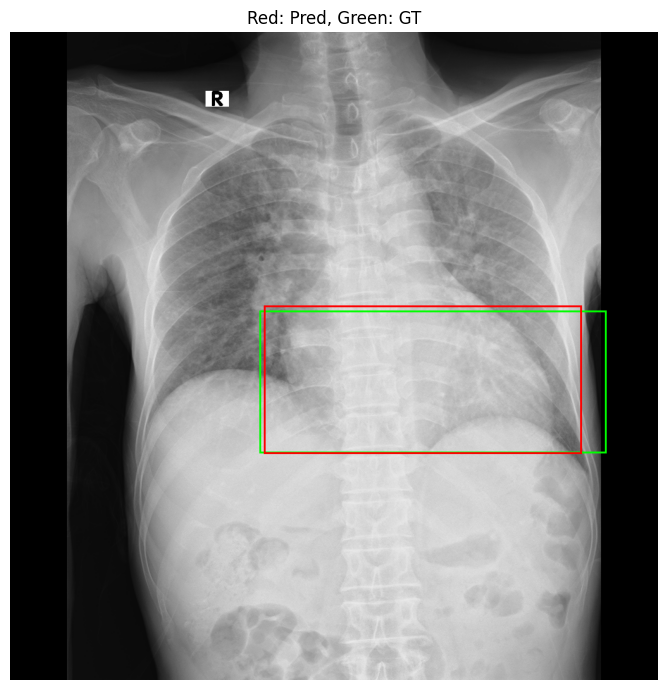

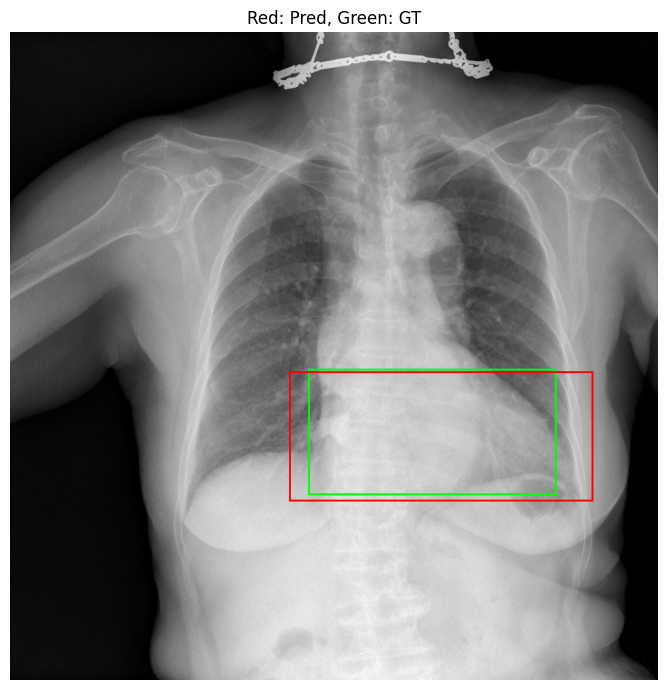

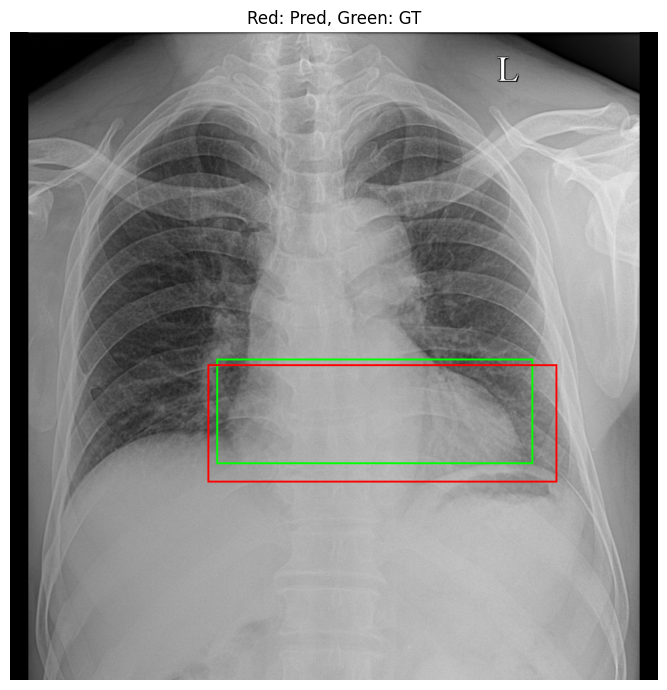

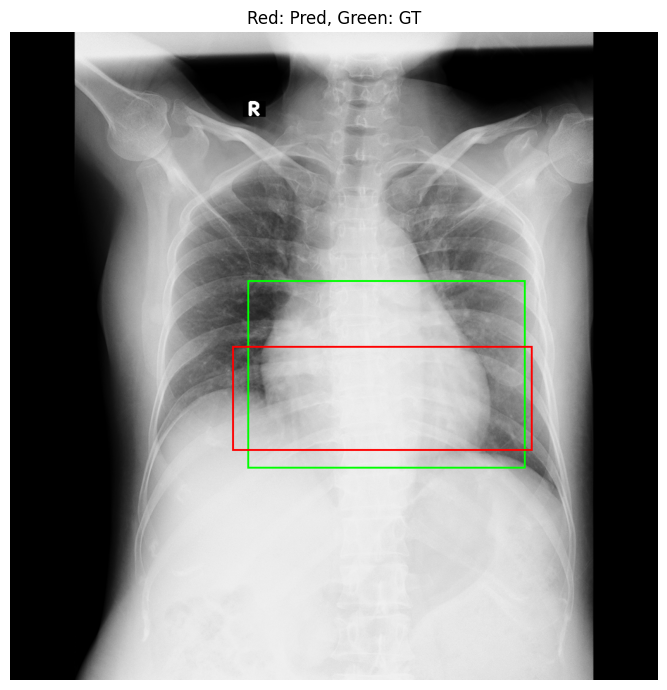

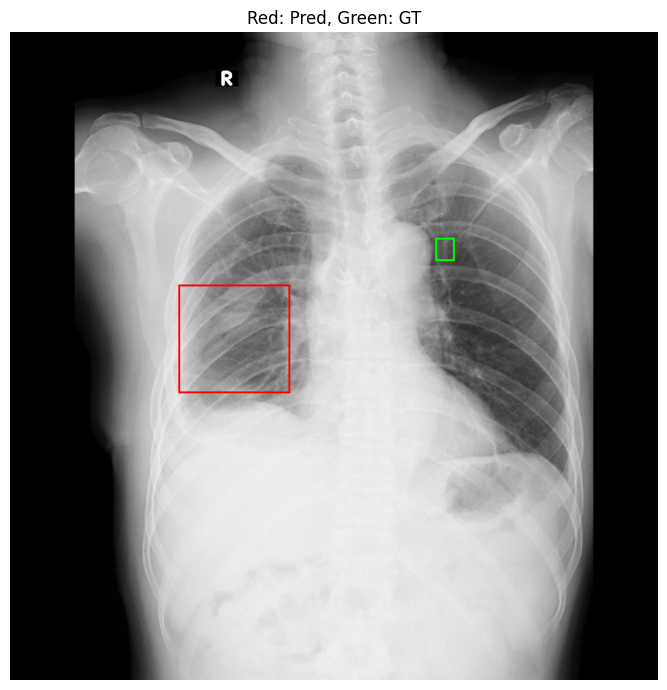

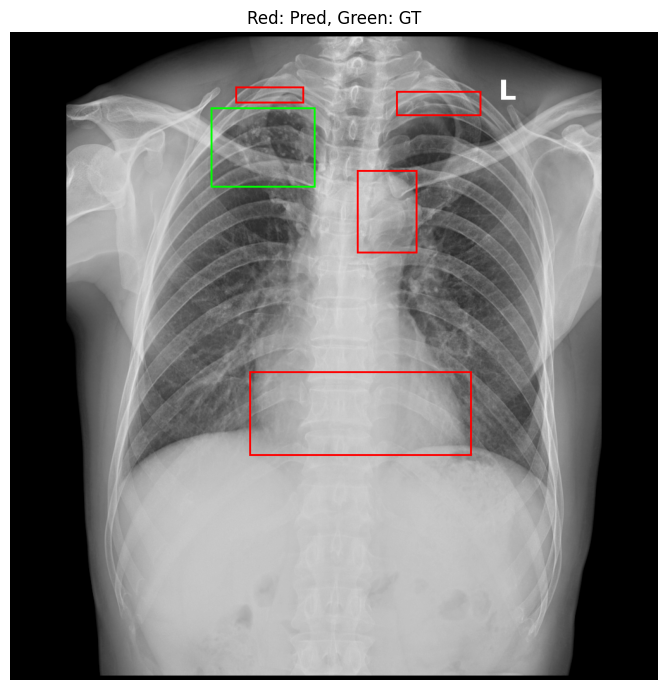

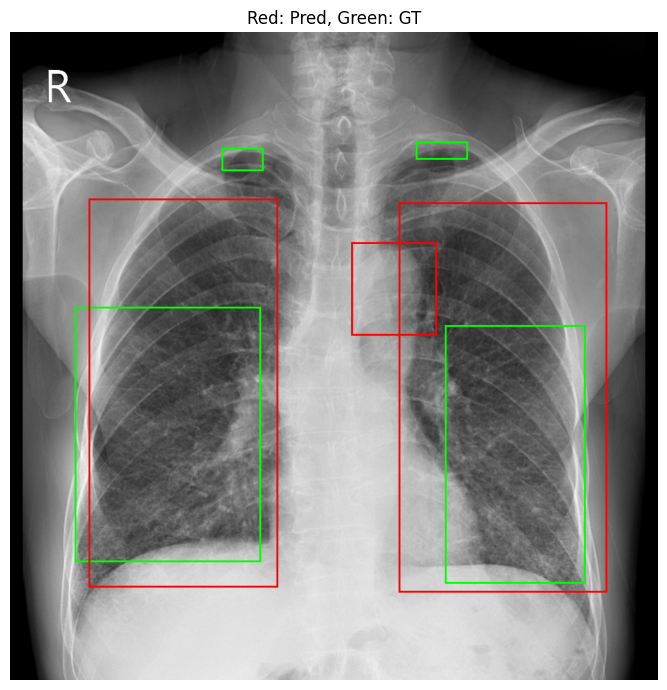

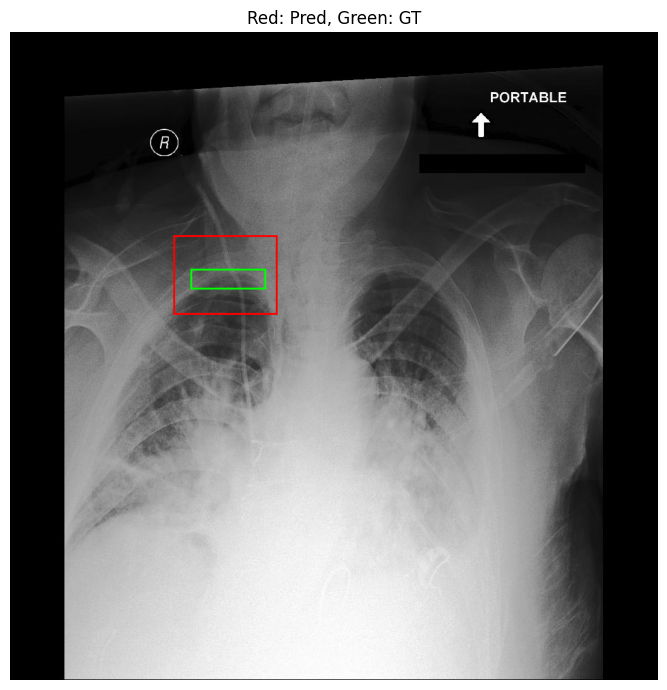

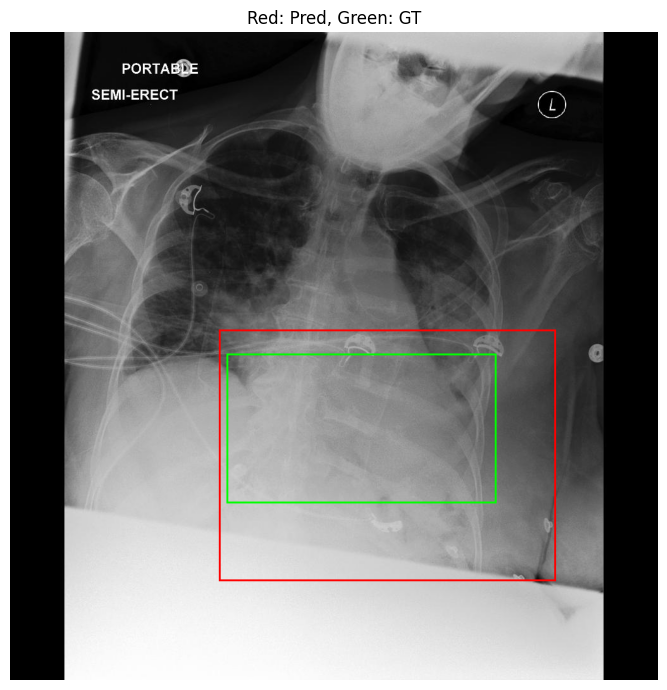

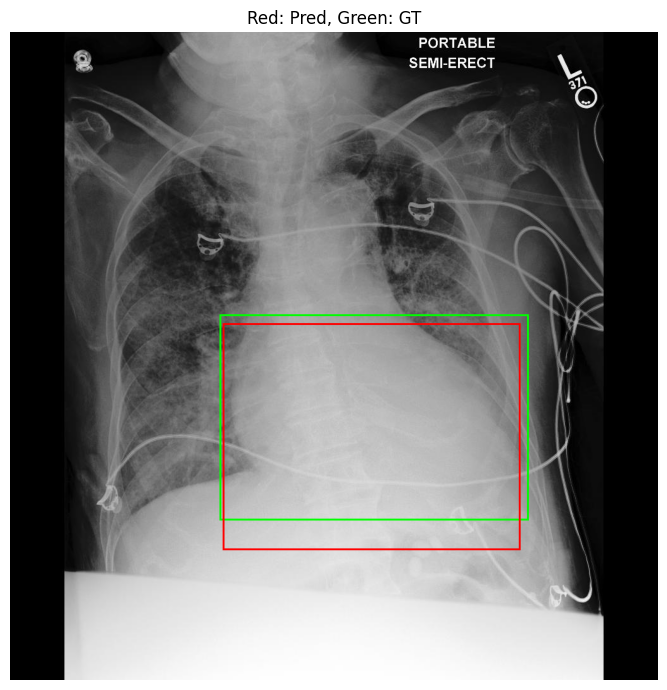

In [45]:
for i in range(len(pred_boxes)):
    img = draw_gt_pred_boxes_tensor(s_boxes[i]['images'], pred_boxes = pred_boxes[i], gt_boxes = gt_boxes[i])
    plt.figure(figsize=(7,7))
    plt.imshow(np.array(img))
    plt.axis('off')
    plt.title("Red: Pred, Green: GT")
    plt.tight_layout()# draw_boxes_tensor(sample['images'], gt_boxes[0])

In [22]:
# out_tokens = model.generate(
#     text = sample['text'], 
#     images = [sample['images']], 
#     decode=False,
#     max_new_tokens=150,
#     retrieve_sentences=True
#     )[0]

# model.tokenizer.decode(out_tokens).split("Task:")[1]

In [23]:
t1 = "<ref> (10,15),(50,667) </ref>"


In [ ]:
i1 = model.tokenizer.tokenizer(t1)

In [ ]:
model.tokenizer.tokenizer.convert_ids_to_tokens(i1.input_ids)

# Grounding Metrics

In [7]:
import os
import sys
import pandas as pd
sys.path.append('/path/to/anatomix/')
from src.data.llm_data import get_task_names

In [8]:
benchmarking_dir = "/path/to/data/experiments/benchmarking/"
dataset = "mscxr"
# dataset = "vindr_instruct"
# dataset = "padchest_gr"

In [32]:
# model_name = [i for i in os.listdir(os.path.join(benchmarking_dir, dataset)) if "mymodel" in i and "ft" in i][-1]
model_name = os.listdir(os.path.join(benchmarking_dir, dataset))[8]
model_name

'chexagent.csv'

In [33]:
tasks = get_task_names('grounding')
tasks

['Anatomy-Grounding',
 'Abnormality Grounding',
 'Abnormality Detection',
 'Grounded Diagnosis',
 'Phrase Grounding',
 'Grounded Captioning']

In [34]:
df = pd.read_csv(os.path.join(benchmarking_dir, dataset, model_name))
print(df.shape)
# df = df[df['task_names'].isin(tasks)]

# df = df[df['task_names'].isin(["Phrase Grounding"])]
print(df.shape)


(528, 6)
(528, 6)


In [35]:
tasknames = df['task_names'].unique()
tasknames

array(['Grounded Diagnosis', 'Phrase Grounding', 'Grounded Captioning'],
      dtype=object)

In [36]:
samples = [df[df['task_names'] == i].sample(5) for i in tasknames]

In [47]:
for sidx, sample in enumerate(samples):
    gt =  sample['gt_res'].tolist()
    res =  sample['model_res'].tolist()
    # prompts = [i.split("Task: ")[1] for i in sample['prompts'].tolist()]
    prompts = sample['prompts'].tolist()

    this_task = tasknames[sidx]
    print(f"Task: {this_task}")


    for i in range(len(gt)):
        print(f"User: {prompts[i]}")
        print(f"Gt: {gt[i]}")
        print(f"Model: {res[i]}")
        if this_task.lower() in ['phrase grounding', "abnormality detection"]:
            print(extract_bounding_boxes_and_refs(gt[i]))
            print("F0" ,extract_bounding_boxes_and_refs(res[i], model = model_name.replace(".csv", "")))
            # print("F1" ,extract_bounding_boxes_and_refs(res[i], format=1))
            # print("F2" ,extract_bounding_boxes_and_refs(res[i], format=2))
            # print(extract_text_and_coords(res[i]))
        print("\n")

    print("\n\n\n")

Task: Grounded Diagnosis
User: Provide a diagnosis based on the content of the following region(s): <box>(223,354),(340,508)</box><box>(644,299),(878,627)</box>
Gt: Consolidation
Model: Consolidation


User: Provide a diagnosis based on the content of the following region(s): <box>(371,522),(927,938)</box>
Gt: Cardiomegaly
Model: Pneumothorax


User: Provide a diagnosis based on the content of the following region(s): <box>(643,366),(768,530)</box>
Gt: Consolidation
Model: Consolidation


User: Provide a diagnosis based on the content of the following region(s): <box>(136,544),(438,728)</box><box>(679,575),(920,831)</box>
Gt: Atelectasis
Model: Pneumothorax


User: Please give the corresponding diagnosis for the following region(s): <box>(372,493),(764,713)</box>
Gt: Cardiomegaly
Model: Pneumonia






Task: Phrase Grounding
User: Identify the position of the following finding in the CXR: cardiac silhouette is enlarged
Gt: <ref>cardiac silhouette is enlarged</ref><box>(243,468),(832,80

In [ ]:
res[0]

In [17]:
import re 

def extract_bounding_boxes_and_refs(text, scale=1):
    """
    Extract [[ref_text_or_plain, [x1,y1,x2,y2]], ...] from a string that may contain:
    - <ref>...</ref>
    - <box>(x1,y1),(x2,y2)</box>
    For each <box>, we pair it with the nearest preceding <ref> in the text
    *since the previous box*, else with the plain text between boxes.
    """
    # Regex to find each <box>(...)</box> with coords inside the outermost parentheses
    box_iter = re.finditer(r"<box>\s*\((.*?)\)\s*</box>", text, flags=re.DOTALL)

    # results = []
    bboxes = []
    texts = []
    last_end = 0  # end position of the previous </box> (or start of text if none)

    for m in box_iter:
        box_inner = m.group(1)

        # ---- Parse numbers: expect four numbers in (x1,y1),(x2,y2) ----
        nums = re.findall(r"-?\d+(?:\.\d+)?", box_inner)
        if len(nums) != 4:
            # Skip malformed box entries
            last_end = m.end()
            continue
        coords = [float(n) * scale for n in nums]

        # ---- Context window: only look between previous </box> and current <box> ----
        context = text[last_end:m.start()]

        # Prefer the *last* <ref>…</ref> in this window
        ref_matches = re.findall(r"<ref>(.*?)</ref>", context, flags=re.DOTALL)
        if ref_matches:
            ref_text = ref_matches[-1].strip()
        else:
            # Fallback to visible text (strip any tags and collapse whitespace)
            visible = re.sub(r"<.*?>", "", context, flags=re.DOTALL).strip()
            # normalize internal whitespace
            ref_text = " ".join(visible.split()) if visible else None
        
        bboxes.append(coords)
        texts.append(ref_text)
        # results.append([ref_text, coords])

        # Advance last_end to after this </box>
        last_end = m.end()

    return bboxes, texts

In [46]:
import re

def extract_bounding_boxes_and_refs(text, scale=1, model='mymodel'):
    """
    Extract [[ref_text_or_plain, [x1,y1,x2,y2]], ...] from a string.

    Supports:
      model = 0 → XML-like <ref>...</ref> and <box>(x1,y1),(x2,y2)</box>
      model = 1 → Plain text "This is an object [x1, y1, x2, y2]"
      model = 2 → Custom markup <|ref|>...</|ref|> <|box|>(x1,y1),(x2,y2)</|box|>
    """
    bboxes, texts = [], []
    last_end = 0

    # Define regex patterns for each model
    if model == 'mymodel':
        box_pattern = r"<box>\s*\((.*?)\)\s*</box>"
        ref_pattern = r"<ref>(.*?)</ref>"
    elif model == 'chexagent':
        box_pattern = r"<\|box\|>\s*\((.*?)\)\s*<\|/box\|>"
        ref_pattern = r"<\|ref\|>(.*?)<\|/ref\|>"
    elif model == 'radvlm': # model == 1 (plain)
        matches = re.finditer(r"(.*?)(\[\s*[-\d.,\s]+\s*\])", text)
        for m in matches:
            visible = m.group(1).strip()
            nums = re.findall(r"-?\d+(?:\.\d+)?", m.group(2))
            if len(nums) != 4:
                continue
            coords = [float(n) * scale for n in nums]
            ref_text = " ".join(visible.split()) if visible else None
            texts.append(ref_text)
            bboxes.append(coords)
        return bboxes, texts

    # Shared logic for tag-based models
    box_iter = re.finditer(box_pattern, text, flags=re.DOTALL)
    for m in box_iter:
        box_inner = m.group(1)
        nums = re.findall(r"-?\d+(?:\.\d+)?", box_inner)
        if len(nums) != 4:
            last_end = m.end()
            continue

        coords = [float(n) * scale for n in nums]
        context = text[last_end:m.start()]

        # Find the nearest preceding ref text
        ref_matches = re.findall(ref_pattern, context, flags=re.DOTALL)
        if ref_matches:
            ref_text = ref_matches[-1].strip()
        else:
            visible = re.sub(r"<.*?>", "", context, flags=re.DOTALL).strip()
            ref_text = " ".join(visible.split()) if visible else None

        texts.append(ref_text)
        bboxes.append(coords)
        last_end = m.end()

    return bboxes, texts


In [ ]:
extract_bounding_boxes_and_refs("<ref>something</ref><box>(10,15),(2,30)</box> and this <box>(10,15),(2,30)</box>")

In [ ]:
extract_bounding_boxes_and_refs("<ref>something</ref><box>(10,15),(2,30)</box> and this <box>(10,15),(2,30)</box>")

In [ ]:
extract_bounding_boxes_and_refs("<ref>something</ref><box>(10,15),(2,30)</box> and <ref>this</ref> <box>(10,15),(2,30)</box>")

In [ ]:
# [['something', ['A', 'B', 'C', 'D']]]

extract_bounding_boxes_and_refs("something <box>(A,B),(C,D)</box>")
# [['something', ['A', 'B', 'C', 'D']]]

extract_bounding_boxes_and_refs("<ref>something</ref><box>(1,2),(3,4)</box>", scale=2)
# [['something', [2.0, 4.0, 6.0, 8.0]]]

extract_bounding_boxes_and_refs("<ref>something</ref><box>(A,B),(C,D)</box> <ref>something else</ref><box>(e,f),(g,h)</box>")
# [['something', ['A', 'B', 'C', 'D']], ['something else', ['e', 'f', 'g', 'h']]]


In [1]:
from torchmetrics.functional.detection import intersection_over_union, mean_average_precision
import torch


/path/to/data/envs/vlm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

# Example data
hyp_boxes = [[260, 412, 850, 812]]
ref_boxes = [[255, 410, 855, 820]]
pred_labels = [0]  # just one label for this example

# Wrap each in a list!
result = mean_average_precision(
    preds=[{
        'boxes': torch.tensor(hyp_boxes, dtype=torch.float32),
        'scores': torch.tensor([1.0 for _ in hyp_boxes]),  # must be float tensor
        'labels': torch.tensor(pred_labels, dtype=torch.int64)
    }],
    target=[{
        'boxes': torch.tensor(ref_boxes, dtype=torch.float32),
        'labels': torch.tensor([1 for _ in ref_boxes], dtype=torch.int64)
    }]
)

print(result)

{'map': tensor(1.), 'map_50': tensor(1.), 'map_75': tensor(1.), 'map_small': tensor(-1.), 'map_medium': tensor(-1.), 'map_large': tensor(1.), 'mar_1': tensor(1.), 'mar_10': tensor(1.), 'mar_100': tensor(1.), 'mar_small': tensor(-1.), 'mar_medium': tensor(-1.), 'mar_large': tensor(1.), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


/path/to/data/envs/vlm/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


In [2]:
model = SentenceTransformer('all-MiniLM-L6-v2', device = 'cuda:1')

ProxyError: (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /api/models/sentence-transformers/all-MiniLM-L6-v2/tree/main/additional_chat_templates?recursive=False&expand=False (Caused by ProxyError('Unable to connect to proxy. Your proxy appears to only use HTTP and not HTTPS, try changing your proxy URL to be HTTP. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#https-proxy-error-http-proxy', SSLError(SSLError(1, '[SSL] record layer failure (_ssl.c:1006)'))))"), '(Request ID: 890a5185-982b-4e64-9a3b-c2f916963ced)')

In [8]:

pred_texts = ["red car", "sports vehicle", "dog"]
true_texts = ["red sports car", "dog"]

emb_pred = model.encode(pred_texts, normalize_embeddings=True)
emb_true = model.encode(true_texts, normalize_embeddings=True)

In [9]:
import torch
sim_matrix = util.cos_sim(emb_pred, emb_true)
print(sim_matrix)


tensor([[0.8678, 0.3543],
        [0.7394, 0.2698],
        [0.2498, 1.0000]])


In [11]:
THRESH = 0.8
matches = sim_matrix > THRESH


In [12]:
matches

tensor([[ True, False],
        [False, False],
        [False,  True]])

In [13]:
from sklearn.metrics import average_precision_score

# Sort predictions by confidence
confidences = [0.93, 0.80, 0.99]
true_matches = [1, 0, 1]  # 1 if matched with sim ≥ THRESH
ap = average_precision_score(true_matches, confidences)
print("AP:", ap)


AP: 1.0


In [ ]:
pred_texts = ["red car", "sports vehicle", "dog", "blue dog"]
true_texts = ["red sports car", "dog"]

In [ ]:
all_texts = true_texts + pred_texts
# embeddings = model.encode(all_texts, normalize_embeddings=True)

In [ ]:
class_map = {}
next_id = 0
for gt in true_texts:
    if gt not in class_map:
        class_map[gt] = next_id
        next_id += 1

pred_labels_ids = []
for p in pred_texts:
    # compute similarity to each gt_text and pick highest
    sims = util.cos_sim(model.encode(p, normalize_embeddings=True),
                        model.encode(list(class_map.keys()), normalize_embeddings=True))
    best_idx = torch.argmax(sims)
    if sims[0, best_idx] >= 0.8:
        pred_labels_ids.append(class_map[list(class_map.keys())[best_idx]])
    else:
        # optionally assign new class or ignore
        pred_labels_ids.append(next_id)
        class_map[p] = next_id
        next_id += 1

In [ ]:
class_map

{'red sports car': 0, 'dog': 1, 'sports vehicle': 2, 'blue dog': 3}

In [37]:
import torch
from torchmetrics.detection import MeanAveragePrecision
from sentence_transformers import src.util

def semantic_mean_ap(
    map_model,
    gt_texts,
    gt_boxes,
    pred_texts,
    pred_boxes,
    pred_scores,
    sim_thresh=0.8,
    device="cpu"
):
    """
    Compute mAP using semantic similarity threshold for free-text labels,
    but if numeric labels are passed, skip the embedding step.

    Args:
        gt_texts (list[str] | list[int]): Ground-truth labels
        gt_boxes (list[list[float]]): Ground-truth bboxes [x1, y1, x2, y2]
        pred_texts (list[str] | list[int]): Predicted labels
        pred_boxes (list[list[float]]): Predicted bboxes [x1, y1, x2, y2]
        pred_scores (list[float]): Prediction confidences
        sim_thresh (float): Cosine similarity threshold for label match
        device (str): Device for SentenceTransformer (only used if text labels)
    """

    # --- Case 1: numeric labels provided, skip similarity ---
    if isinstance(gt_texts[0], (int, float)) and isinstance(pred_texts[0], (int, float)):
        gt_class_ids = torch.tensor(gt_texts, dtype=torch.int64)
        pred_class_ids = torch.tensor(pred_texts, dtype=torch.int64)

    # --- Case 2: free-text labels → use semantic similarity ---
    else:
        gt_emb = map_model.encode(gt_texts, normalize_embeddings=True, convert_to_tensor=True)
        pred_emb = map_model.encode(pred_texts, normalize_embeddings=True, convert_to_tensor=True)

        # Compute cosine similarity
        sim_matrix = util.cos_sim(pred_emb, gt_emb)

        # Build semantic mapping from pred_texts -> gt_texts
        gt_class_map = {t: i for i, t in enumerate(gt_texts)}  # assign IDs
        pred_class_ids = []
        for i, p in enumerate(pred_texts):
            sims = sim_matrix[i]
            best_j = torch.argmax(sims)
            if sims[best_j] >= sim_thresh:
                pred_class_ids.append(best_j.item())
            else:
                # assign a new ID for unmatched text
                pred_class_ids.append(len(gt_class_map) + i)
        gt_class_ids = torch.arange(len(gt_texts), dtype=torch.int64)

    # --- Build TorchMetrics input ---
    preds = [{
        "boxes": torch.tensor(pred_boxes, dtype=torch.float32),
        "scores": torch.tensor(pred_scores, dtype=torch.float32),
        "labels": torch.tensor(pred_class_ids, dtype=torch.int64)
    }]
    targets = [{
        "boxes": torch.tensor(gt_boxes, dtype=torch.float32),
        "labels": torch.tensor(gt_class_ids, dtype=torch.int64)
    }]

    metric = MeanAveragePrecision()
    metric.update(preds, targets)
    res = metric.compute()
    return res, gt_class_ids, pred_class_ids


In [10]:
import os
os.environ["http_proxy"]="http://172.28.7.1:3128"
os.environ["https_proxy"]="http://172.28.7.1:3128"
os.environ["all_proxy"]="http://172.28.7.1:3128"
os.environ["no_proxy"]="localhost,*.chimera.hpc.mssm.edu,172.28.0.0/16"

from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2', device = 'cuda:1')


In [11]:
os.environ['TOKENIZERS_PARALLELISM']="false"

In [44]:
result = semantic_mean_ap(
    model,
    gt_texts=["red sports car", "dog"],
    # gt_texts=[1, 2],
    pred_texts=["red car", "sports vehicle", "dog"],
    # pred_texts=[2, 2,],
    gt_boxes=[[50, 50, 200, 200], [30, 40, 100, 120]],
    pred_boxes=[[55, 55, 195, 195], [60, 60, 210, 210], [28, 35, 105, 125]],
    pred_scores=[0.9, 0.8, 0.95],
    sim_thresh=0.8
)

# print(result["map"], result["map_50"])


/tmp/ipykernel_1562998/3877703950.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "labels": torch.tensor(gt_class_ids, dtype=torch.int64)


In [45]:
result

({'map': tensor(0.7500),
  'map_50': tensor(1.),
  'map_75': tensor(1.),
  'map_small': tensor(-1.),
  'map_medium': tensor(0.7000),
  'map_large': tensor(0.8000),
  'mar_1': tensor(0.7500),
  'mar_10': tensor(0.7500),
  'mar_100': tensor(0.7500),
  'mar_small': tensor(-1.),
  'mar_medium': tensor(0.7000),
  'mar_large': tensor(0.8000),
  'map_per_class': tensor(-1.),
  'mar_100_per_class': tensor(-1.),
  'classes': tensor([0, 1, 3], dtype=torch.int32)},
 tensor([0, 1]),
 [0, 3, 1])

# Checking If Inference was completed

In [1]:
import os

In [3]:
bench_dir = "/path/to/data/experiments/benchmarking"
phrase = "ft_c_patch"

In [4]:
for dataset_name in os.listdir(bench_dir):
    files = os.listdir(os.path.join(bench_dir, dataset_name))
    files = [i for i in files if phrase in i]
    if len(files) == 0:
        print(dataset_name)

mimic_vqa
